<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/Dataset%20Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces/channe14_NLOS_cluster5.hdf5"

In [4]:
RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [5]:
file_path2 = "/content/drive/MyDrive/Project/Project1/processed/channe14_NLOS_cluster5.npy"

In [6]:
import numpy as np

data = np.load(file_path2, allow_pickle=True)
print(type(data))

<class 'numpy.ndarray'>


In [7]:
print(data.shape)
print(data.dtype)
print(data[:2])   # preview first few entries

(4063, 72)
float32
[[-0.15963328 -0.3797324   1.8300391   1.1080043   0.68789476  1.3072621
   1.7712178   1.6247216   2.0869777   1.0246181   1.7025442   3.4321897
   2.0349584  -0.07307489  1.0640887   3.0399153   2.0452118   1.093672
   2.5897498   2.7177818   0.59292877  0.83192325  1.9483751   2.3225234
   1.0233037   1.5568123   2.2442698   1.6311204   1.0616003   0.8793211
   2.4822628   1.5082828   0.9855445   1.3826135   2.4996934   2.1544297
   1.0145766   2.4405456   2.6891894   1.3824917   2.6921122   3.0474198
   1.6121436   2.188162    2.8967946   3.1325176   1.5222108   1.5132799
   2.5106156   4.172838    3.562508    3.3897986   5.125084    4.030868
   3.2191212   4.550522    3.6545563   4.244471    2.64178     3.256511
  -1.4220409   4.3566523   2.4789925   3.4261153   1.7756687   2.5133586
   2.7316036   2.8737342   1.9115229   2.3995836   3.3645658   2.934043  ]
 [-0.23689955 -0.38619134  1.773393    1.0442642   0.75161546  1.3521782
   1.7794082   1.7047175   2.1222

In [8]:
print(data.dtype)

float32


In [9]:
import numpy as np

print("Min:", np.min(data))
print("Max:", np.max(data))

Min: -4.1362634
Max: 6.6755066


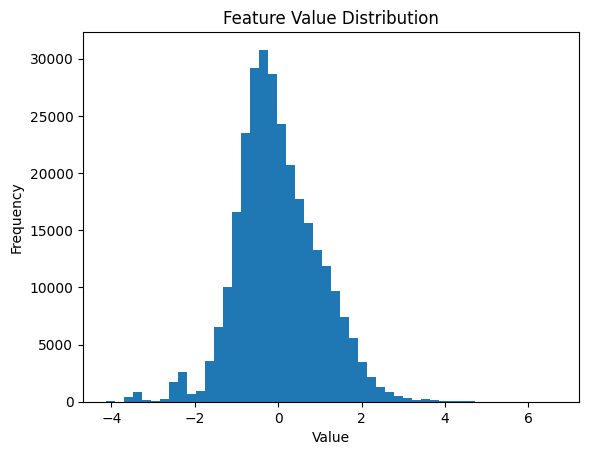

In [14]:
import matplotlib.pyplot as plt

plt.hist(data.flatten(), bins=50)
plt.title("Feature Value Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

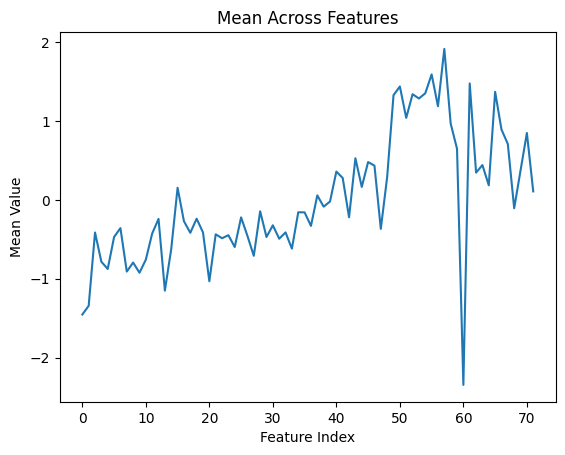

In [15]:
mean_vals = np.mean(data, axis=0)

plt.plot(mean_vals)
plt.title("Mean Across Features")
plt.xlabel("Feature Index")
plt.ylabel("Mean Value")
plt.show()

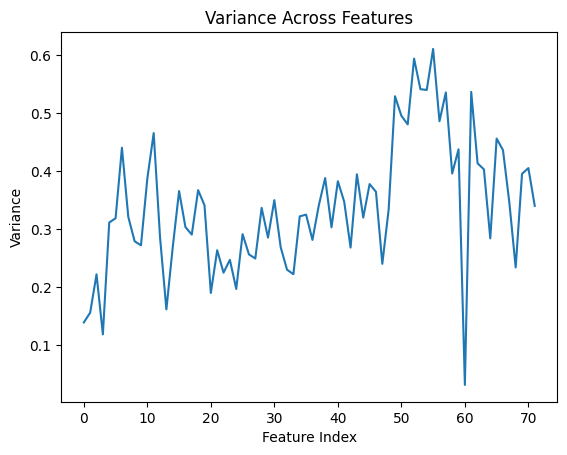

In [17]:
var_vals = np.var(data, axis=0)

plt.plot(var_vals)
plt.title("Variance Across Features")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

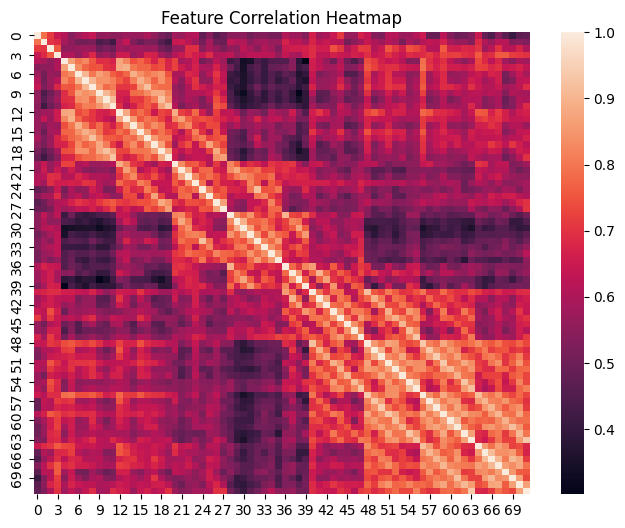

In [18]:
import seaborn as sns

corr = np.corrcoef(data.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr)
plt.title("Feature Correlation Heatmap")
plt.show()

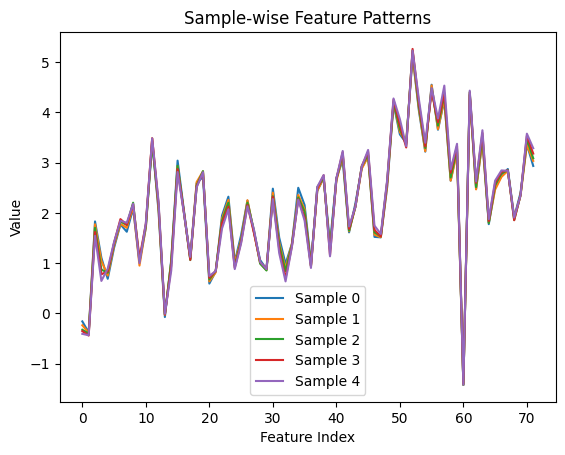

In [19]:
for i in range(5):
    plt.plot(data[i], label=f"Sample {i}")

plt.legend()
plt.title("Sample-wise Feature Patterns")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.show()

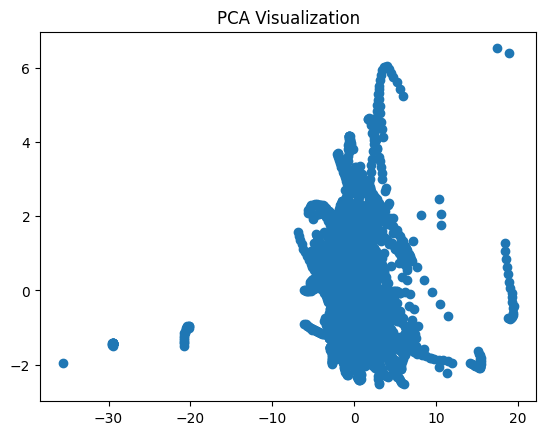

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(data)

plt.scatter(reduced[:,0], reduced[:,1])
plt.title("PCA Visualization")
plt.show()

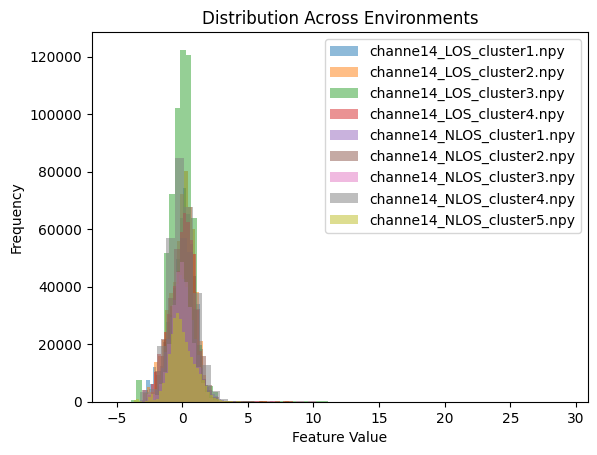

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt

for file in sorted(os.listdir(PROCESSED_DIR)):
    data = np.load(os.path.join(PROCESSED_DIR, file), allow_pickle=True)

    plt.hist(data.flatten(), bins=50, alpha=0.5, label=file)

plt.legend()
plt.title("Distribution Across Environments")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()

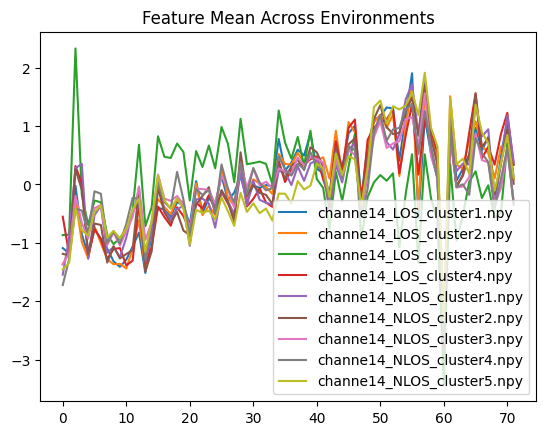

In [28]:
for file in sorted(os.listdir(PROCESSED_DIR)):
    data = np.load(os.path.join(PROCESSED_DIR, file))
    mean_vals = np.mean(data, axis=0)

    plt.plot(mean_vals, label=file)

plt.legend()
plt.title("Feature Mean Across Environments")
plt.show()

/tmp/ipykernel_6455/59061042.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_data, labels=labels, showfliers=False)


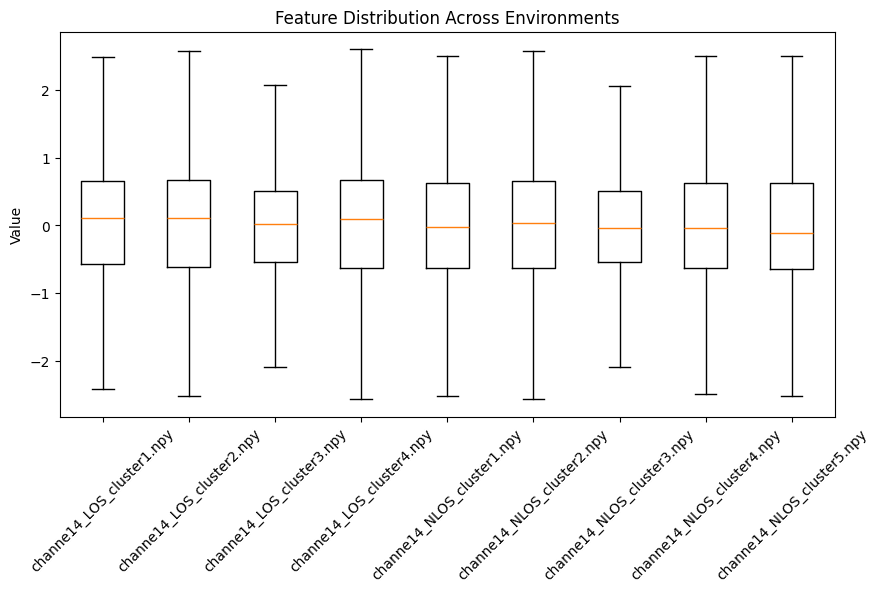

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

all_data = []
labels = []

for file in sorted(os.listdir(PROCESSED_DIR)):
    if file.endswith(".npy"):
        data = np.load(os.path.join(PROCESSED_DIR, file), allow_pickle=True)

        all_data.append(data.flatten())
        labels.append(file)

plt.figure(figsize=(10,5))
plt.boxplot(all_data, labels=labels, showfliers=False)
plt.xticks(rotation=45)
plt.title("Feature Distribution Across Environments")
plt.ylabel("Value")
plt.show()

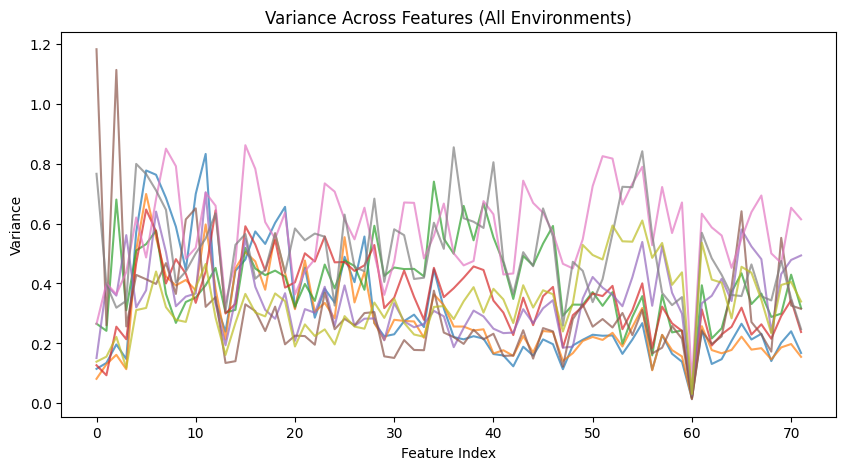

In [33]:
plt.figure(figsize=(10,5))

for file in sorted(os.listdir(PROCESSED_DIR)):
    if file.endswith(".npy"):
        data = np.load(os.path.join(PROCESSED_DIR, file), allow_pickle=True)
        var_vals = np.var(data, axis=0)

        plt.plot(var_vals, alpha=0.7)

plt.title("Variance Across Features (All Environments)")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

In [34]:
data = np.load(file_path2, allow_pickle=True)

In [35]:
import numpy as np

# data shape: (samples, features)
var_vals = np.var(data, axis=0)

# Get top 10 feature indices
top10_var_idx = np.argsort(var_vals)[-10:][::-1]

print("Top 10 features (by variance):", top10_var_idx)

Top 10 features (by variance): [55 52 53 54 61 57 49 50 56 51]


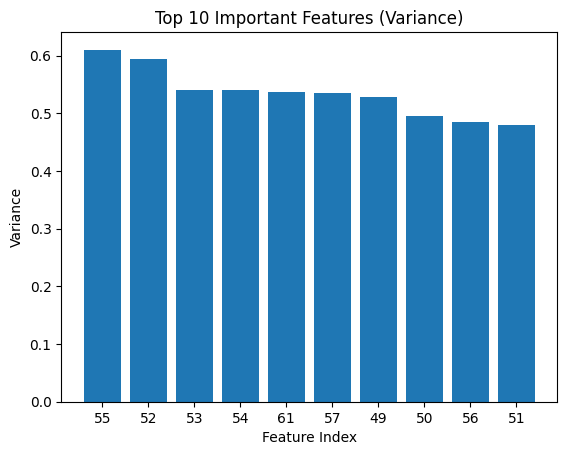

In [39]:
import matplotlib.pyplot as plt

top_idx = top10_var_idx

plt.bar(range(10), var_vals[top_idx])
plt.xticks(range(10), top_idx)
plt.title("Top 10 Important Features (Variance)")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

In [26]:
print("Mean:", np.mean(data))
print("Std:", np.std(data))

Mean: -4.4910088e-08
Std: 1.0
